In [6]:
import numpy as np
import os
import pickle
import shutil
from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.models import load_model
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from IPython.display import Video
from tqdm.notebook import tqdm

In [12]:
# Configuration
source_root = 'cropped_img'
base_dir = 'prepared_data'
# Your new 3 classes
classes = ['Handicap', 'Reserved', 'Unreserved']

# Create destination folders
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Process Files
for cls in classes:
    src_path = os.path.join(source_root, cls)

    # Check if folder exists
    if not os.path.exists(src_path):
        print(f"Warning: Folder {src_path} not found. Skipping...")
        continue

    # List all images
    files = [f for f in os.listdir(src_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(files) == 0:
        print(f"No images found in {src_path}")
        continue

    # Split 80% train, 20% test
    train_files, test_files = train_test_split(files, test_size=0.20, random_state=42)

    # Helper function to copy
    def copy_files(file_list, split_name):
        for f in file_list:
            src = os.path.join(src_path, f)
            dst = os.path.join(base_dir, split_name, cls, f)
            shutil.copy(src, dst)

    copy_files(train_files, 'train')
    copy_files(test_files, 'test')

print(f"Data reorganized successfully! Classes: {classes}")

Data reorganized successfully! Classes: ['Handicap', 'Reserved', 'Unreserved']


In [8]:
img_width, img_height = 48, 48
train_data_dir = 'prepared_data/train'
validation_data_dir = 'prepared_data/test'
batch_size = 32
epochs = 15

# Data Augmentation helps "equilibrate" the learning process
# by creating variations of minority classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

# This handles the "equilibrated" weight calculation automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))

print(f"Weights to balance classes: {train_class_weights}")

Found 25 images belonging to 3 classes.
Found 7 images belonging to 3 classes.
Weights to balance classes: {0: np.float64(1.1904761904761905), 1: np.float64(0.6944444444444444), 2: np.float64(1.3888888888888888)}


In [13]:
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# 2. Freeze the layers (don't retrain the basic shapes)
for layer in base_model.layers:
    layer.trainable = False

# 3. Add your own "head" for your specific classes
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights
)

model.save('parking_model_v1.h5')

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4000 - loss: 1.4385 - val_accuracy: 0.4286 - val_loss: 1.0306
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3600 - loss: 1.2982 - val_accuracy: 0.4286 - val_loss: 0.8830
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4400 - loss: 1.0353 - val_accuracy: 1.0000 - val_loss: 0.7717
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step - accuracy: 0.4000 - loss: 1.0123 - val_accuracy: 1.0000 - val_loss: 0.6800
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - accuracy: 0.6000 - loss: 0.8912 - val_accuracy: 1.0000 - val_loss: 0.6009
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step - accuracy: 0.8800 - loss: 0.7011 - val_accuracy: 1.0000 - val_loss: 0.5299
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step - accuracy: 0.6400 - loss: 0.6513 - val_accuracy: 1.0000 - val_loss: 0.4687
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step - accuracy: 0.7200 - loss: 0.6967 - val_accuracy: 1.0000 - val_loss: 0.4164
E

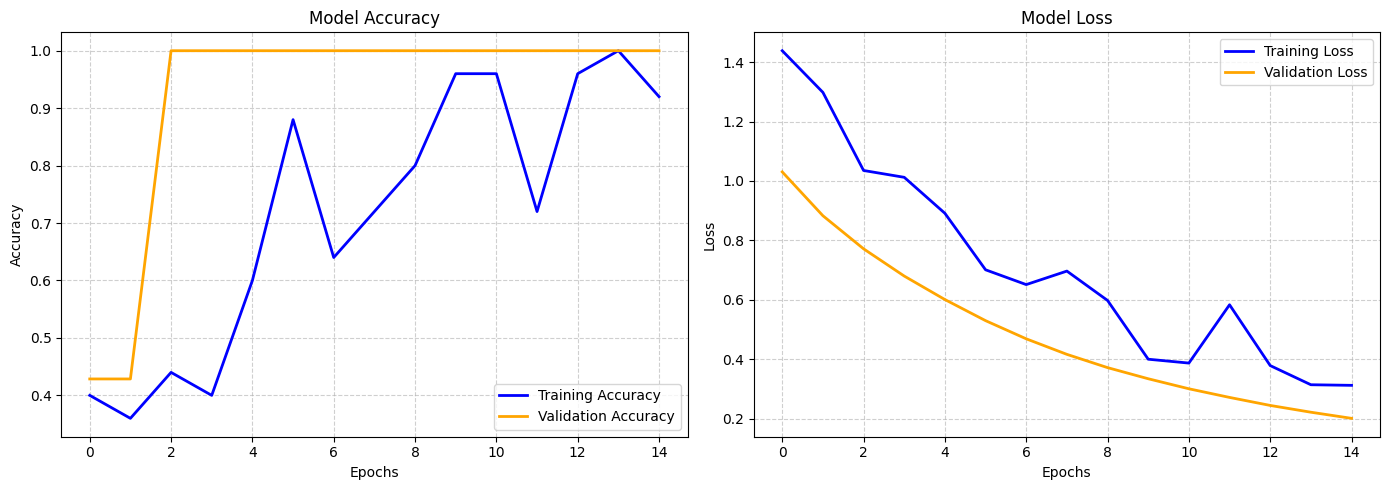

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

In [ ]:
# 1. LOAD DATA & MODEL
model = load_model('parking_model_v1.h5')
with open('./car_position_parking.pkl', 'rb') as f:
    posList = pickle.load(f)

# Box dimensions (Ensure these match your picker session)
width, height = 40, 65

# 2. VIDEO SETUP
cap = cv2.VideoCapture('parking.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('processed.mp4', fourcc, fps, (frame_w, frame_h))

# --- CONFIGURATION ---
SKIP_FRAMES = 2  # Only run AI every 5th frame (Change to 1 for no skip)
last_results = [] # To store the classifications between skips

def checkParkingSpace(img):
    img_crops = []
    active_positions = []

    for pos in posList:
        x, y = pos
        imgCrop = img[y:y + height, x:x + width]

        if imgCrop.size == 0 or imgCrop.shape[0] < 5 or imgCrop.shape[1] < 5:
            continue

        imgResize = cv2.resize(imgCrop, (48, 48), interpolation=cv2.INTER_LANCZOS4)
        imgNormalized = imgResize.astype('float32') / 255.0
        img_crops.append(imgNormalized)
        active_positions.append(pos)

    if len(img_crops) > 0:
        # BATCH PREDICT: This is the massive speed boost
        batch_array = np.array(img_crops)
        predictions = model.predict(batch_array, verbose=0)
        class_indices = np.argmax(predictions, axis=1)

        # Return results to be "remembered" for skipped frames
        return list(zip(active_positions, class_indices))
    return []

# 3. MAIN PROCESSING LOOP
for frame_idx in tqdm(range(total_frames), desc="Batching & Skipping"):
    success, frame = cap.read()
    if not success:
        break

    # Only run the heavy AI logic every SKIP_FRAMES
    if frame_idx % SKIP_FRAMES == 0:
        last_results = checkParkingSpace(frame)

    # Always draw the results (either fresh or from the last checked frame)
    for pos, class_idx in last_results:
        x, y = pos

        # Color Logic
        if class_idx == 0: color = (255, 0, 0)      # H-Reserved
        elif class_idx == 1: color = (255, 255, 0)  # H-Unreserved
        elif class_idx == 2: color = (0, 0, 255)    # R-Reserved
        else: color = (0, 255, 0)                  # R-Unreserved

        thickness = 5 if class_idx == 0 else 2
        cv2.rectangle(frame, (x, y), (x + width, y + height), color, thickness)

    out.write(frame)

cap.release()
out.release()

Batching & Skipping:   0%|          | 0/910 [00:00<?, ?it/s]